# Tracking Metrics on Eritrea

Very little open data exists on Eritrea. This notebook joins multiple indicators — port activity, humanitarian flows, conflict events, population, and rainfall — to monitor what is happening inside the country.

**Data sources:**
- [PortWatch (FAO/Oxford)](https://portwatch.mapbox.com/) — ship calls and trade tonnage at Massawa
- [HDX HAPI](https://hapi.humdata.org/) — humanitarian indicators (refugees, returnees, funding, population, rainfall, conflict)
- [WHO via HDX](https://data.humdata.org/dataset/who-data-for-eri) — health indicators (manual download)

## 0. Environment Setup

Credentials are stored in a local `.env` file 

Create a `.env` file at the root of this project:
```
HDX_APP_IDENTIFIER=your_base64_identifier_here
```
Add `.env` to your `.gitignore`.

In [1]:
import os
import time
import requests
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")

In [2]:
# --- Credentials ---
load_dotenv()
HDX_APP_IDENTIFIER = os.getenv("HDX_APP_IDENTIFIER")
if not HDX_APP_IDENTIFIER:
    raise EnvironmentError(
        "HDX_APP_IDENTIFIER not found. "
        "Create a .env file with HDX_APP_IDENTIFIER=<your_token> "
        "and add .env to .gitignore."
    )
print("Credentials loaded.")

# --- Output folders ---
DATA_DIR    = "data"
FIGURES_DIR = "figures"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"Folders ready: {DATA_DIR}/, {FIGURES_DIR}/")

Credentials loaded.
Folders ready: data/, figures/


## 1. Data Loading

All datasets are cached locally under `data/`. On first run (or after 30 days) they are fetched from their respective APIs.

In [3]:
CACHE_DURATION = 30 * 24 * 60 * 60  # 30 days in seconds

def is_cache_valid(filepath: str, max_age: int = CACHE_DURATION) -> bool:
    """Returns True if the file exists and is younger than max_age seconds."""
    if not os.path.exists(filepath):
        return False
    return (time.time() - os.path.getmtime(filepath)) < max_age


PORTWATCH_CACHE = os.path.join(DATA_DIR, "portwatch_eritrea_cache.csv")
PORTWATCH_URL = (
    "https://opendata.arcgis.com/api/v3/datasets/"
    "83b1bbc7b3354c5fb1f40673bb8f852e_0/downloads/data"
    "?format=geojson&spatialRefId=4326&where=1=1"
)

def load_portwatch() -> pd.DataFrame:
    """Load Eritrea port data from PortWatch, using a local cache when available."""
    if is_cache_valid(PORTWATCH_CACHE):
        print("[PortWatch] Loading from cache.")
        return pd.read_csv(PORTWATCH_CACHE)

    print("[PortWatch] Cache missing or expired — fetching from API...")
    try:
        response = requests.get(PORTWATCH_URL, timeout=60).json()
        features = [f["properties"] for f in response.get("features", [])]
        df_all = pd.DataFrame(features)
        df_all.columns = df_all.columns.str.upper()
        df_eri = df_all[df_all["ISO3"] == "ERI"].copy()  # keep only Eritrea
        df_eri.to_csv(PORTWATCH_CACHE, index=False)
        print("[PortWatch] Data fetched and cached.")
        return df_eri
    except Exception as e:
        if os.path.exists(PORTWATCH_CACHE):
            print(f"[PortWatch] Fetch failed ({e}). Falling back to expired cache.")
            return pd.read_csv(PORTWATCH_CACHE)
        raise


df_eri = load_portwatch()

numeric_cols = [
    "PORTCALLS", "IMPORT", "EXPORT", "YEAR", "MONTH",
    "PORTCALLS_TANKER", "PORTCALLS_DRY_BULK", "PORTCALLS_GENERAL_CARGO",
]
df_eri[numeric_cols] = df_eri[numeric_cols].apply(pd.to_numeric, errors="coerce")

port_summary = df_eri.groupby("PORTNAME").agg(
    total_ships=("PORTCALLS", "sum"),
    total_imports=("IMPORT", "sum"),
    total_exports=("EXPORT", "sum"),
    days_tracked=("DATE", "count"),
).reset_index()

print("\n--- Port Summary (all time) ---")
print(port_summary.to_string(index=False))

[PortWatch] Cache missing or expired — fetching from API...
[PortWatch] Data fetched and cached.

--- Port Summary (all time) ---
PORTNAME  total_ships  total_imports  total_exports  days_tracked
 Massawa          726        2096536        2595626          2720


In [7]:
HDX_BASE_URL = "https://hapi.humdata.org/api/v2"
LOCATION     = "Eritrea"

HDX_DATASETS = {
    "Returnees_Eritrea.csv":       "affected-people/returnees",
    "Conflict_Events_Eritrea.csv": "coordination-context/conflict-events",
    "Funding_Eritrea.csv":         "coordination-context/funding",
    "Rainfall_Eritrea.csv":        "climate/rainfall",
}

def load_hdx_dataset(filename: str, route: str) -> None:
    """Download an HDX dataset to data/ if absent or expired."""
    filepath = os.path.join(DATA_DIR, filename)
    if is_cache_valid(filepath):
        age_days = int((time.time() - os.path.getmtime(filepath)) / 86400)
        print(f"  [OK] {filename} ({age_days}d old)")
        return

    print(f"  [--] {filename} — fetching...")
    params = {
        "app_identifier": HDX_APP_IDENTIFIER,
        "location_name":  LOCATION,
        "output_format":  "csv",
        "page_size":      10000,
    }
    try:
        response = requests.get(f"{HDX_BASE_URL}/{route}", params=params, timeout=30)
        if response.status_code == 200:
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(response.text)
            print(f"       -> Saved to {filepath}")
        else:
            print(f"       -> API error {response.status_code}")
    except Exception as e:
        print(f"       -> Connection error: {e}")


print("Checking HDX datasets...")
for fname, route in HDX_DATASETS.items():
    load_hdx_dataset(fname, route)
print("Done.")

Checking HDX datasets...
  [OK] Returnees_Eritrea.csv (0d old)
  [OK] Conflict_Events_Eritrea.csv (0d old)
  [OK] Funding_Eritrea.csv (0d old)
  [OK] Rainfall_Eritrea.csv (0d old)
Done.


In [6]:
# Refugees data is large (35 000+ rows) and requires paginated JSON fetching.
# The result is saved to data/eritrea_refugees.csv.

REFUGEES_CACHE = os.path.join(DATA_DIR, "eritrea_refugees.csv")

def fetch_all_eritrea_refugees() -> pd.DataFrame:
    """Paginate through the HDX refugees endpoint and return a DataFrame."""
    all_data = []
    limit, offset = 10000, 0

    while True:
        params = {
            "app_identifier":     HDX_APP_IDENTIFIER,
            "output_format":      "json",
            "origin_location_code": "ERI",
            "limit":  limit,
            "offset": offset,
        }
        r = requests.get(
            f"{HDX_BASE_URL}/affected-people/refugees-persons-of-concern",
            params=params, timeout=30,
        )
        if r.status_code != 200:
            print("Error:", r.status_code, r.text)
            break
        data = r.json()["data"]
        if not data:
            break
        all_data.extend(data)
        print(f"  Fetched {len(all_data)} rows...")
        if len(data) < limit:
            break
        offset += limit

    return pd.DataFrame(all_data)


if is_cache_valid(REFUGEES_CACHE):
    print(f"[Refugees] Loading from cache ({REFUGEES_CACHE}).")
    df_refugees = pd.read_csv(REFUGEES_CACHE)
else:
    print("[Refugees] Fetching paginated data...")
    df_refugees = fetch_all_eritrea_refugees()
    df_refugees.to_csv(REFUGEES_CACHE, index=False, encoding="utf-8")
    print(f"[Refugees] Saved to {REFUGEES_CACHE}")

df_refugees["reference_period_start"] = pd.to_datetime(
    df_refugees["reference_period_start"], errors="coerce"
)
print(f"Refugees dataset: {len(df_refugees)} rows")

[Refugees] Fetching paginated data...
  Fetched 10000 rows...
  Fetched 20000 rows...
  Fetched 30000 rows...
  Fetched 35672 rows...
[Refugees] Saved to data/eritrea_refugees.csv
Refugees dataset: 35672 rows


## 2. Port Activity — Massawa

In [8]:
monthly = df_eri.groupby(["YEAR", "MONTH"]).sum(numeric_only=True).reset_index()
monthly = monthly.sort_values(["YEAR", "MONTH"]).reset_index(drop=True)

monthly["TOTAL_TONNAGE"]       = monthly["IMPORT"] + monthly["EXPORT"]
monthly["TONS_PER_SHIP"]       = monthly["TOTAL_TONNAGE"] / monthly["PORTCALLS"].replace(0, 1)
monthly["IMPORT_EXPORT_RATIO"] = monthly["IMPORT"] / monthly["EXPORT"].replace(0, 1)

monthly_rolling = monthly.rolling(window=3, min_periods=1).mean()
x_labels = monthly["YEAR"].astype(str) + "-" + monthly["MONTH"].astype(str).str.zfill(2)

print(f"Monthly records: {len(monthly)} months ({monthly['YEAR'].min():.0f} – {monthly['YEAR'].max():.0f})")

Monthly records: 90 months (2019 – 2026)


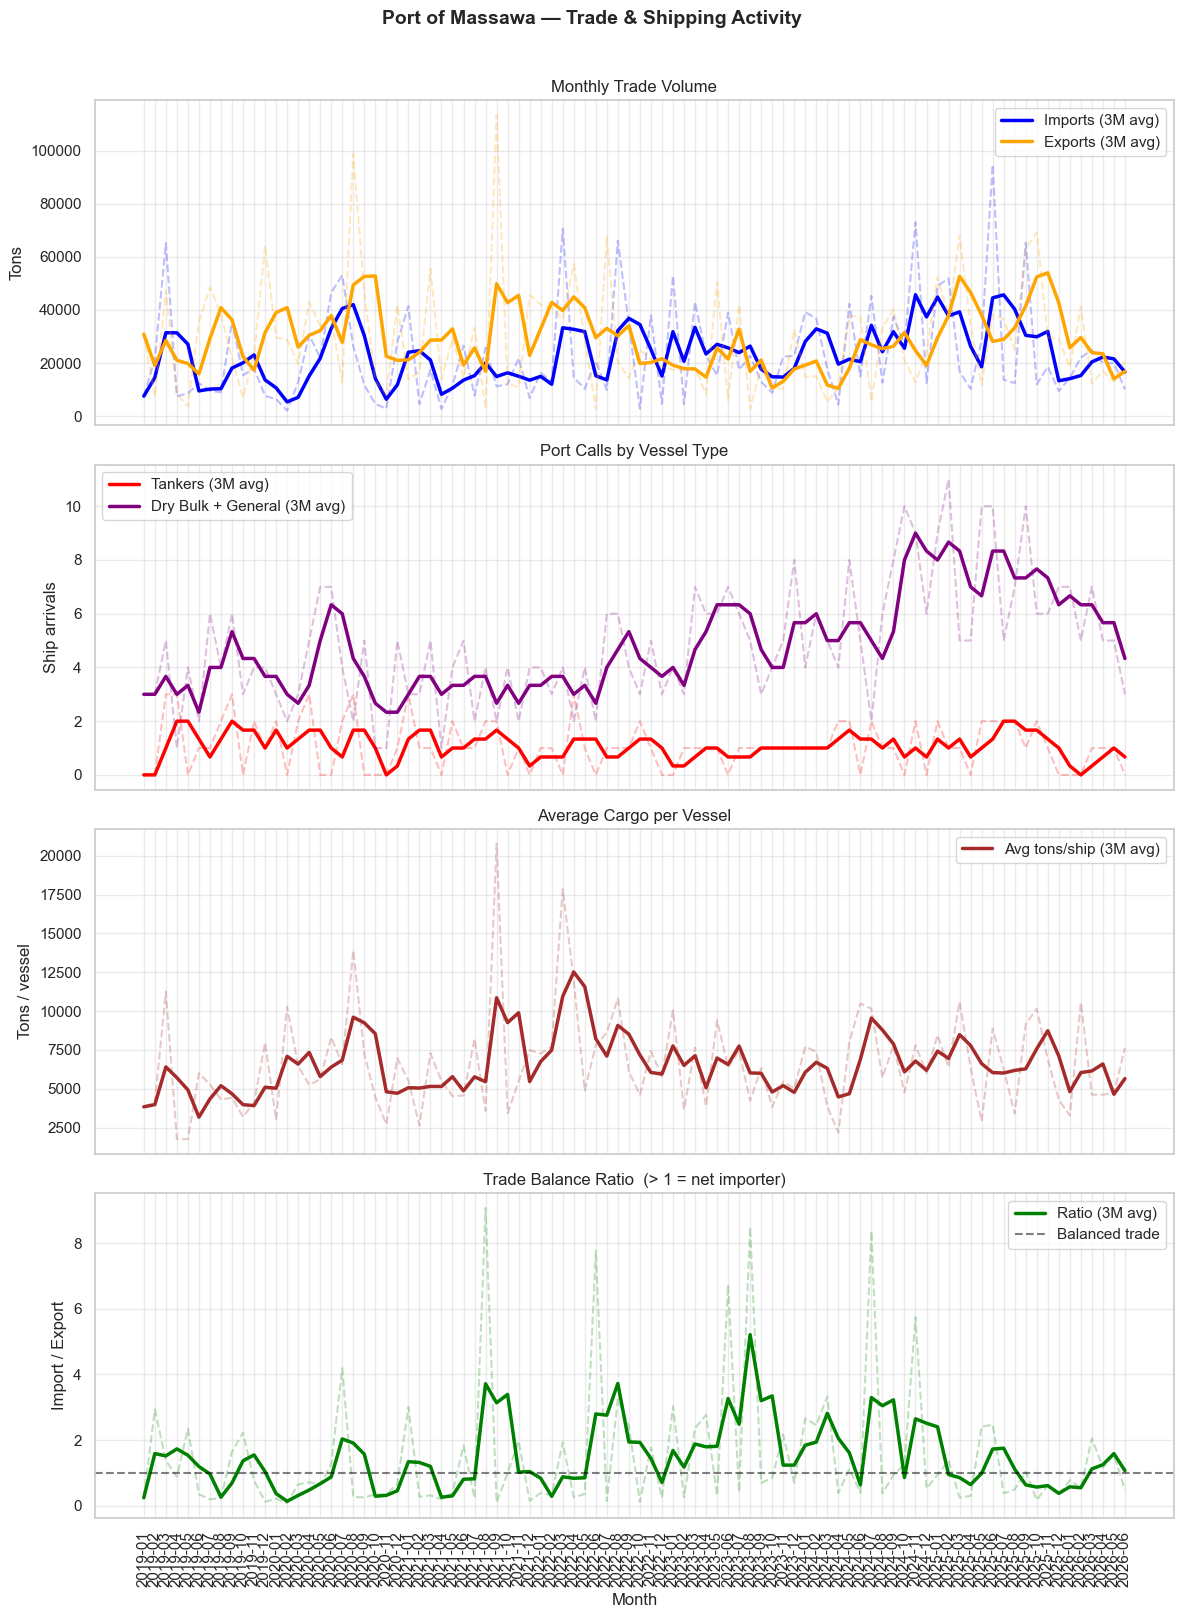

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
fig.suptitle("Port of Massawa — Trade & Shipping Activity", fontsize=14, fontweight="bold", y=1.01)

axes[0].plot(x_labels, monthly["IMPORT"],          color="blue",   alpha=0.25, linestyle="--")
axes[0].plot(x_labels, monthly_rolling["IMPORT"],  color="blue",   linewidth=2.5, label="Imports (3M avg)")
axes[0].plot(x_labels, monthly["EXPORT"],          color="orange", alpha=0.25, linestyle="--")
axes[0].plot(x_labels, monthly_rolling["EXPORT"],  color="orange", linewidth=2.5, label="Exports (3M avg)")
axes[0].set_title("Monthly Trade Volume")
axes[0].set_ylabel("Tons")
axes[0].legend(); axes[0].grid(True, alpha=0.4)

bulk_general         = monthly["PORTCALLS_DRY_BULK"] + monthly["PORTCALLS_GENERAL_CARGO"]
bulk_general_rolling = monthly_rolling["PORTCALLS_DRY_BULK"] + monthly_rolling["PORTCALLS_GENERAL_CARGO"]
axes[1].plot(x_labels, monthly["PORTCALLS_TANKER"],         color="red",    alpha=0.25, linestyle="--")
axes[1].plot(x_labels, monthly_rolling["PORTCALLS_TANKER"], color="red",    linewidth=2.5, label="Tankers (3M avg)")
axes[1].plot(x_labels, bulk_general,                        color="purple", alpha=0.25, linestyle="--")
axes[1].plot(x_labels, bulk_general_rolling,                color="purple", linewidth=2.5, label="Dry Bulk + General (3M avg)")
axes[1].set_title("Port Calls by Vessel Type")
axes[1].set_ylabel("Ship arrivals")
axes[1].legend(); axes[1].grid(True, alpha=0.4)

axes[2].plot(x_labels, monthly["TONS_PER_SHIP"],         color="brown", alpha=0.25, linestyle="--")
axes[2].plot(x_labels, monthly_rolling["TONS_PER_SHIP"], color="brown", linewidth=2.5, label="Avg tons/ship (3M avg)")
axes[2].set_title("Average Cargo per Vessel")
axes[2].set_ylabel("Tons / vessel")
axes[2].legend(); axes[2].grid(True, alpha=0.4)

axes[3].plot(x_labels, monthly["IMPORT_EXPORT_RATIO"],         color="green", alpha=0.25, linestyle="--")
axes[3].plot(x_labels, monthly_rolling["IMPORT_EXPORT_RATIO"], color="green", linewidth=2.5, label="Ratio (3M avg)")
axes[3].axhline(1, color="black", linestyle="--", alpha=0.5, label="Balanced trade")
axes[3].set_title("Trade Balance Ratio  (> 1 = net importer)")
axes[3].set_ylabel("Import / Export")
axes[3].set_xlabel("Month")
axes[3].legend(); axes[3].grid(True, alpha=0.4)

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "massawa_dashboard.png"), dpi=150, bbox_inches="tight")
plt.show()

In [11]:
yearly = monthly.groupby("YEAR")[["IMPORT", "EXPORT", "PORTCALLS"]].sum()
yearly["BALANCE"] = yearly["EXPORT"] - yearly["IMPORT"]

print("=== Annual Totals ===")
print(yearly.to_string())

avg_ratio = monthly["IMPORT_EXPORT_RATIO"].mean()
print(f"\nAverage import/export ratio: {avg_ratio:.2f}  (> 1 = persistent net importer)")

peak = monthly.loc[monthly["IMPORT"].idxmax()]
print(f"Peak import month: {peak['YEAR']:.0f}-{peak['MONTH']:.0f}  ({peak['IMPORT']:,.0f} tons)")

=== Annual Totals ===
      IMPORT  EXPORT  PORTCALLS  BALANCE
YEAR                                    
2019  217992  336388        112   118396
2020  246792  412623         99   165831
2021  189410  361810         88   172400
2022  301313  375354         81    74041
2023  284445  234392         84   -50053
2024  362733  257579         92  -105154
2025  382705  495186        127   112481
2026  111146  122294         43    11148

Average import/export ratio: 1.49  (> 1 = persistent net importer)
Peak import month: 2025-6  (94,737 tons)


## 3. Humanitarian Funding

Aggregated Yearly Financial Summary:
 year  requirements_usd  funding_usd
 2000               0.0      2611218
 2001       133195034.0     95914151
 2002        92343068.0     59248588
 2003       159963824.0    164091516
 2004       125542804.0     86408520
 2005       156681835.0    120109185
 2006        18348120.0     36800529
 2007               0.0     25693666
 2008               0.0     18652872
 2009               0.0     16546782
 2010               0.0     16445633
 2011               0.0      8582375
 2012               0.0     19678482
 2013               0.0      4799372
 2014               0.0      4157333
 2015               0.0      6336029
 2016               0.0      8825235
 2017               0.0      3546507
 2018               0.0     14130421
 2019               0.0     11750557
 2020               0.0     13802903
 2021               0.0     10048531
 2022               0.0      8948877
 2023               0.0     10884394
 2024               0.0      8160669
 

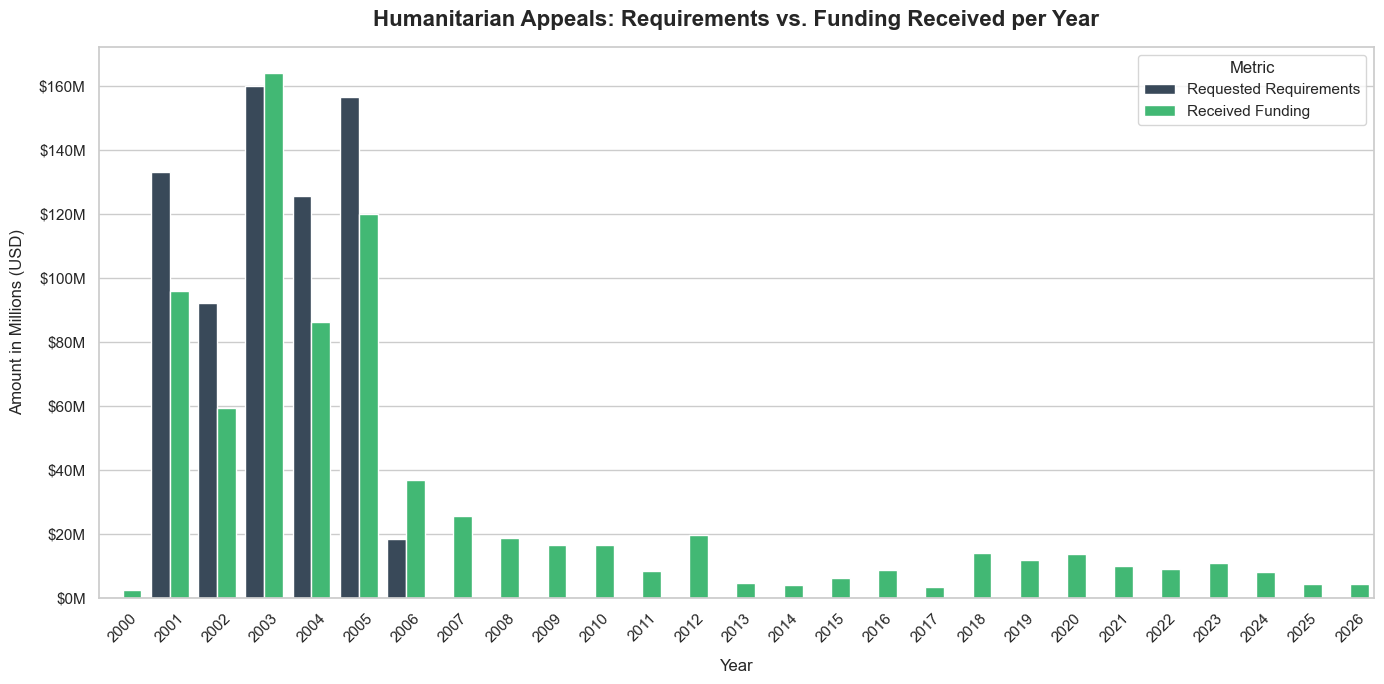

In [12]:
df_fund = pd.read_csv(os.path.join(DATA_DIR, "Funding_Eritrea.csv"))
df_fund["reference_period_start"] = pd.to_datetime(df_fund["reference_period_start"])
df_fund["year"] = df_fund["reference_period_start"].dt.year
df_fund[["requirements_usd", "funding_usd"]] = df_fund[["requirements_usd", "funding_usd"]].fillna(0)

yearly_fund = df_fund.groupby("year")[["requirements_usd", "funding_usd"]].sum().reset_index()
print("Aggregated Yearly Financial Summary:")
print(yearly_fund.to_string(index=False))

melted = yearly_fund.melt(
    id_vars="year",
    value_vars=["requirements_usd", "funding_usd"],
    var_name="Financial Type",
    value_name="Amount (USD)",
)
melted["Financial Type"] = melted["Financial Type"].map({
    "requirements_usd": "Requested Requirements",
    "funding_usd":      "Received Funding",
})

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=melted, x="year", y="Amount (USD)", hue="Financial Type",
    palette=["#34495e", "#2ecc71"],
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x * 1e-6:.0f}M"))
plt.title("Humanitarian Appeals: Requirements vs. Funding Received per Year",
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Year", labelpad=10)
plt.ylabel("Amount in Millions (USD)", labelpad=10)
plt.xticks(rotation=45)
plt.legend(title="Metric", loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "humanitarian_funding_per_year.png"), dpi=300)
plt.show()

## 4. Conflict Events

Period: 2003 – 2026
Total events: 145  |  Total fatalities: 1245


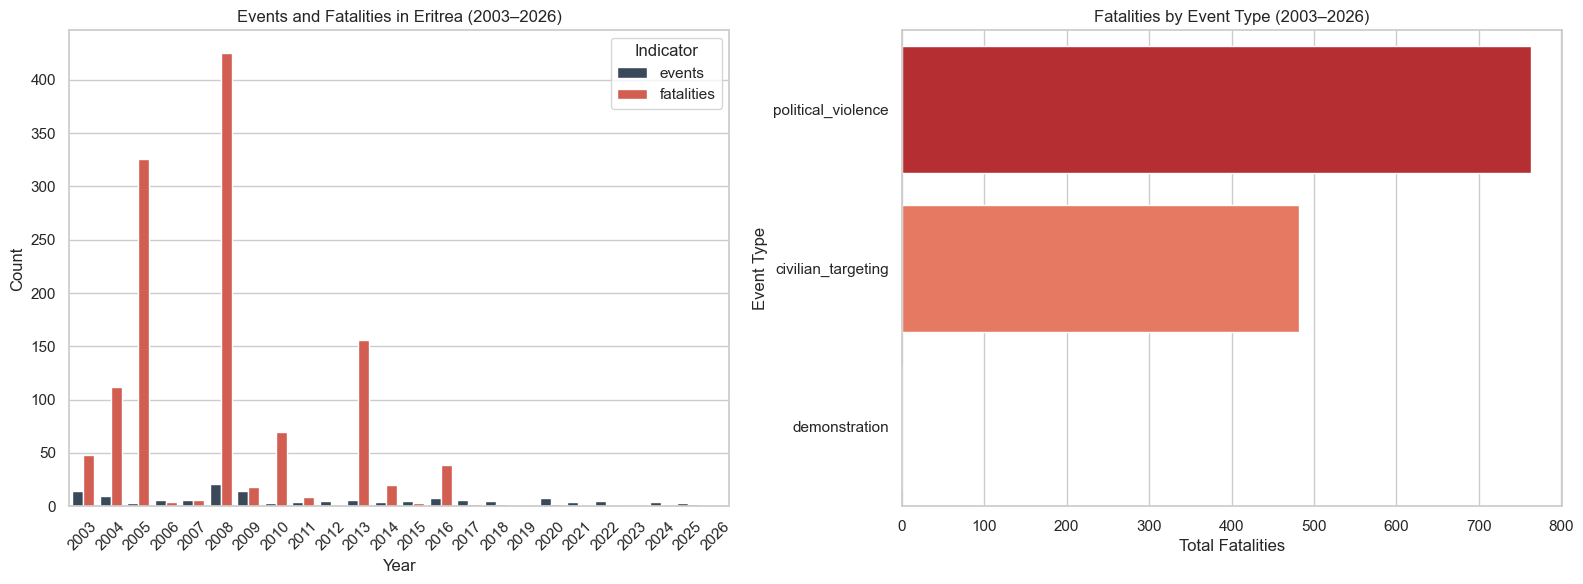

In [13]:
df_conf = pd.read_csv(os.path.join(DATA_DIR, "Conflict_Events_Eritrea.csv"))
df_conf["reference_period_start"] = pd.to_datetime(df_conf["reference_period_start"])
df_conf["year"] = df_conf["reference_period_start"].dt.year
df_conf[["events", "fatalities"]] = df_conf[["events", "fatalities"]].fillna(0).astype(int)

# Filter from 2003 onwards (sparse data before that)
df_conf = df_conf[df_conf["year"] >= 2003].copy()
print(f"Period: {df_conf['year'].min()} – {df_conf['year'].max()}")
print(f"Total events: {df_conf['events'].sum()}  |  Total fatalities: {df_conf['fatalities'].sum()}")

yearly_conf = df_conf.groupby("year")[["events", "fatalities"]].sum().reset_index()
event_fatality = (
    df_conf.groupby("event_type")["fatalities"].sum()
    .reset_index().sort_values("fatalities", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

melted_conf = yearly_conf.melt(id_vars="year", value_vars=["events", "fatalities"],
                                var_name="Indicator", value_name="Total")
sns.barplot(data=melted_conf, x="year", y="Total", hue="Indicator",
            palette=["#34495e", "#e74c3c"], ax=axes[0])
axes[0].set_title("Events and Fatalities in Eritrea (2003–2026)")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=event_fatality, x="fatalities", y="event_type",
            hue="event_type", legend=False, palette="Reds_r", ax=axes[1])
axes[1].set_title("Fatalities by Event Type (2003–2026)")
axes[1].set_xlabel("Total Fatalities"); axes[1].set_ylabel("Event Type")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "conflict_analysis_2003_2026.png"), dpi=300)
plt.show()

## 5. Rainfall

Records: 3213
Cumulative rainfall: 149054.55 mm
Long-term average:   130186.81 mm


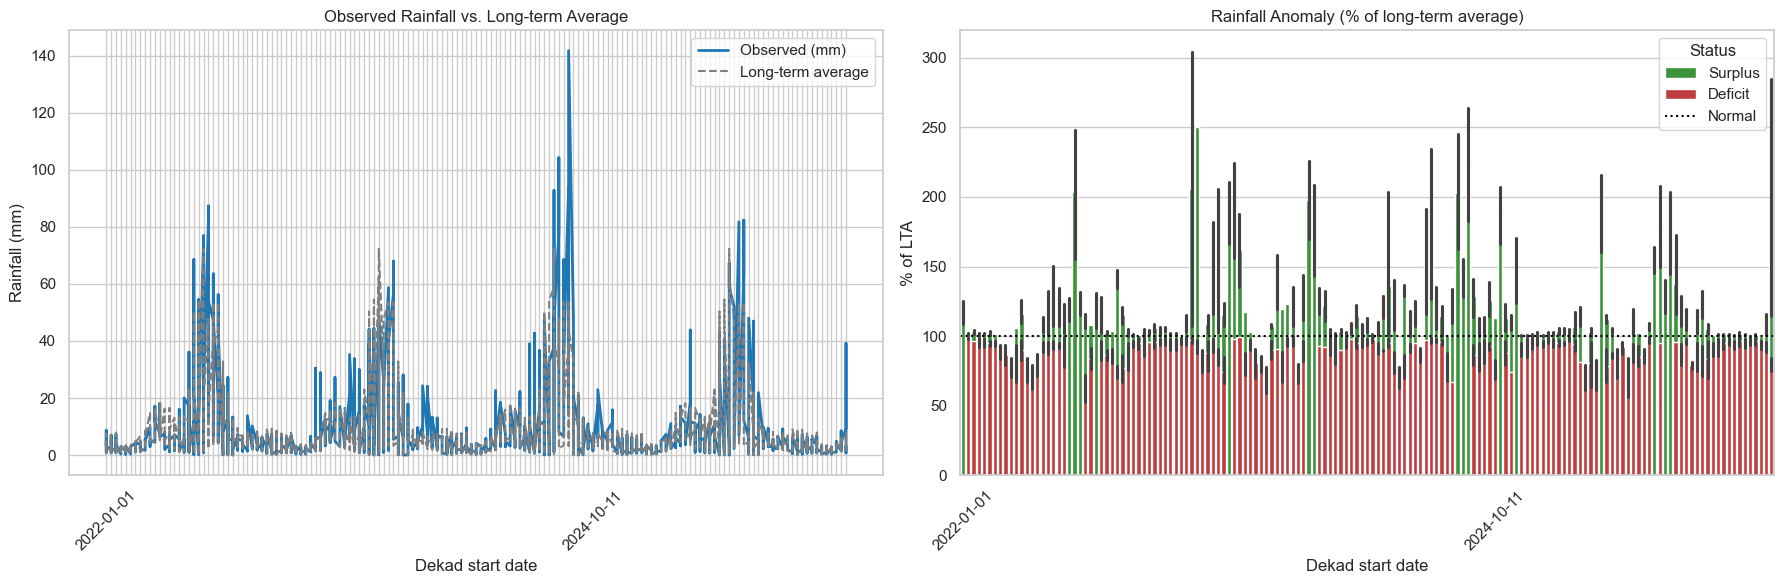


Average dekad rainfall by region:
         admin1_name  rainfall  rainfall_long_term_average  rainfall_anomaly_pct
               Debub 16.075684                   14.837469            106.826811
              Maekel 14.620915                   12.775960            104.636915
          Gash Barka 13.742941                   12.268544            107.493279
              Anseba 11.155007                    8.830887            111.410904
Semienawi Keih Bahri  7.027789                    6.141123            106.238760
 Debubawi Keih Bahri  5.448281                    4.532157            107.996553


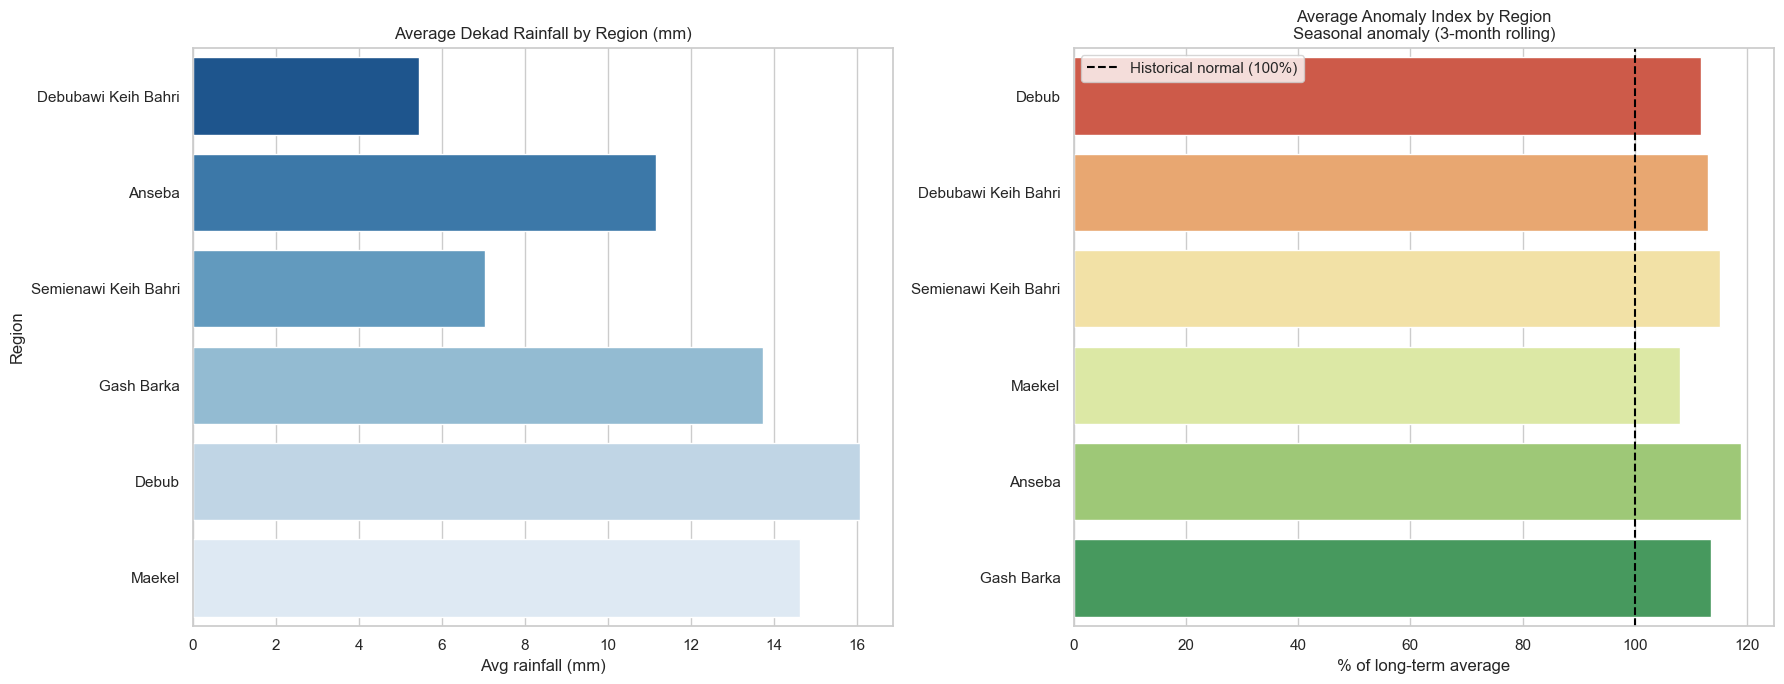

In [14]:
df_rain = pd.read_csv(os.path.join(DATA_DIR, "Rainfall_Eritrea.csv"))
df_rain["reference_period_start"] = pd.to_datetime(df_rain["reference_period_start"])
df_rain = df_rain.sort_values("reference_period_start").reset_index(drop=True)
df_rain["date_label"] = df_rain["reference_period_start"].dt.strftime("%Y-%m-%d")
df_rain["year"] = df_rain["reference_period_start"].dt.year

print(f"Records: {len(df_rain)}")
print(f"Cumulative rainfall: {df_rain['rainfall'].sum():.2f} mm")
print(f"Long-term average:   {df_rain['rainfall_long_term_average'].sum():.2f} mm")

# Dekad-level data only (avoids mixing aggregation periods)
df_dekad = df_rain[df_rain["aggregation_period"] == "dekad"].copy()

# --- Plot 1: Observed vs historical average (national) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(df_dekad["date_label"], df_dekad["rainfall"],
             linewidth=2, color="#1f77b4", label="Observed (mm)")
axes[0].plot(df_dekad["date_label"], df_dekad["rainfall_long_term_average"],
             linestyle="--", color="#7f7f7f", label="Long-term average")
axes[0].fill_between(df_dekad["date_label"],
                     df_dekad["rainfall"], df_dekad["rainfall_long_term_average"],
                     where=(df_dekad["rainfall"] >= df_dekad["rainfall_long_term_average"]),
                     color="gainsboro", alpha=0.4)
axes[0].set_title("Observed Rainfall vs. Long-term Average")
axes[0].set_xlabel("Dekad start date"); axes[0].set_ylabel("Rainfall (mm)")
axes[0].legend()

df_dekad["status"] = df_dekad["rainfall_anomaly_pct"].apply(
    lambda x: "Surplus" if x >= 100 else "Deficit"
)
sns.barplot(data=df_dekad, x="date_label", y="rainfall_anomaly_pct",
            hue="status", palette={"Surplus": "#2ca02c", "Deficit": "#d62728"},
            dodge=False, ax=axes[1])
axes[1].axhline(100, color="black", linestyle="dotted", linewidth=1.5, label="Normal")
axes[1].set_title("Rainfall Anomaly (% of long-term average)")
axes[1].set_xlabel("Dekad start date"); axes[1].set_ylabel("% of LTA")
axes[1].legend(title="Status")

# Thin out x-axis labels to avoid overlap
for ax in axes:
    for i, label in enumerate(ax.get_xticklabels()):
        label.set_visible(i % 100 == 0)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "rainfall_national.png"), dpi=300)
plt.show()

# --- Plot 2: Regional comparison ---
regional_stats = (
    df_dekad.groupby("admin1_name")[["rainfall", "rainfall_long_term_average", "rainfall_anomaly_pct"]]
    .mean().reset_index().sort_values("rainfall", ascending=False)
)
print("\nAverage dekad rainfall by region:")
print(regional_stats.to_string(index=False))

df_anom = df_rain[df_rain["aggregation_period"] == "3-month"]
if df_anom.empty:
    df_anom = df_dekad
    anom_label = "Dekad anomaly (10-day)"
else:
    anom_label = "Seasonal anomaly (3-month rolling)"

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=df_dekad, x="rainfall", y="admin1_name", hue="admin1_name",
            legend=False, palette="Blues_r", errorbar=None, ax=axes[0])
axes[0].set_title("Average Dekad Rainfall by Region (mm)")
axes[0].set_xlabel("Avg rainfall (mm)"); axes[0].set_ylabel("Region")

sns.barplot(data=df_anom, x="rainfall_anomaly_pct", y="admin1_name", hue="admin1_name",
            legend=False, palette="RdYlGn", errorbar=None, ax=axes[1])
axes[1].axvline(100, color="black", linestyle="--", linewidth=1.5, label="Historical normal (100%)")
axes[1].set_title(f"Average Anomaly Index by Region\n{anom_label}")
axes[1].set_xlabel("% of long-term average"); axes[1].set_ylabel("")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "rainfall_regional_comparison.png"), dpi=300)
plt.show()

## 6. Returnees

Rows: 10000  |  Period: 2001 – 2024

Top origins by returnee volume:
            origin_location_name  population
Democratic Republic of the Congo    25743976
                     Afghanistan    21306701
                        Ethiopia    12612357
                            Iraq     9755286
                        Pakistan     9013190
                     Philippines     5031148
        Central African Republic     4404791
                         Myanmar     3084299
                   Côte d'Ivoire     2725867
                         Burundi     2263378
                         Nigeria     2011458
                           Libya     1848058
                        Cameroon     1671993
                         Lebanon     1540747
                      Mozambique     1437779
                         Liberia     1423291
                            Mali     1104502
                          Angola      694667
                      Kyrgyzstan      434505
          Bosnia and Herzegovin

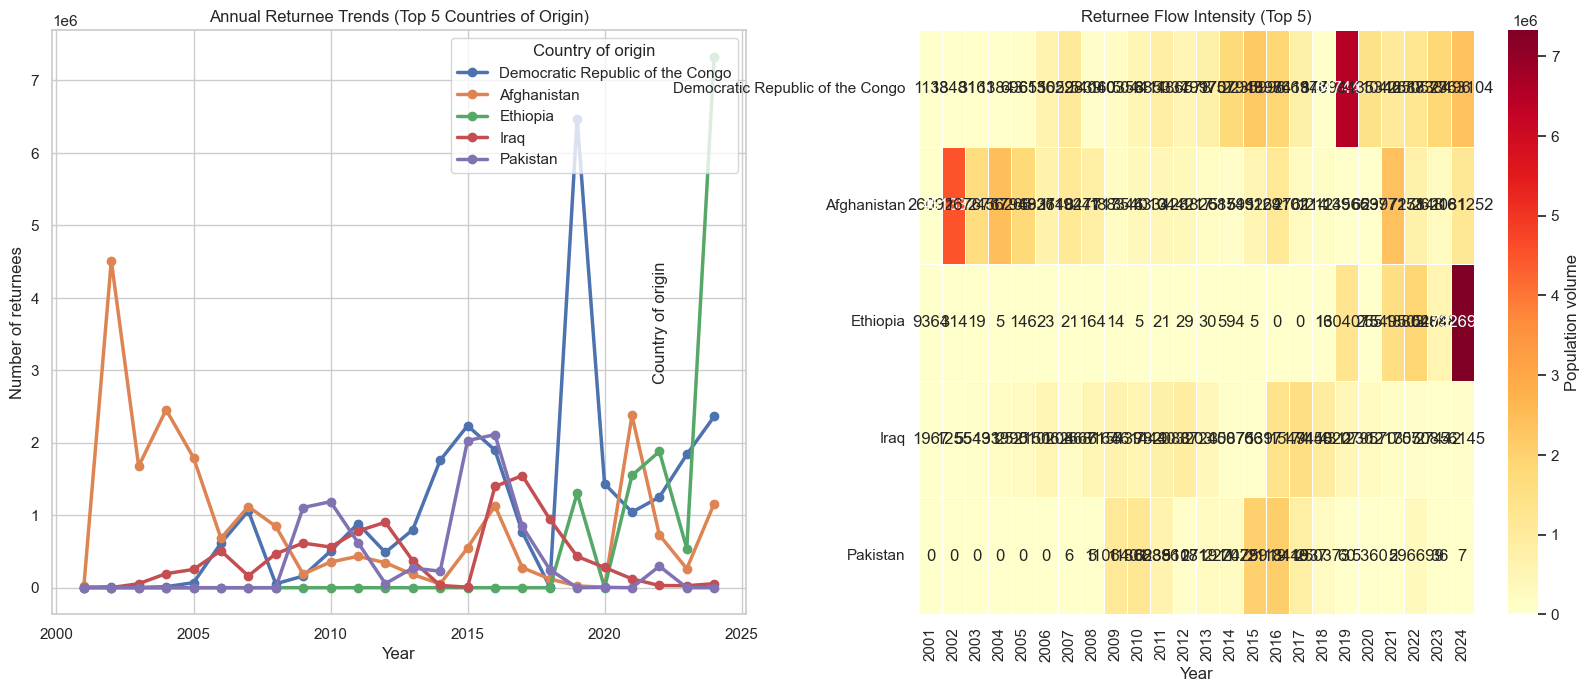

In [15]:
df_ret = pd.read_csv(os.path.join(DATA_DIR, "Returnees_Eritrea.csv"), on_bad_lines="skip")
df_ret["reference_period_start"] = pd.to_datetime(df_ret["reference_period_start"])
df_ret["year"] = df_ret["reference_period_start"].dt.year
df_ret["population"] = pd.to_numeric(df_ret["population"], errors="coerce").fillna(0)

print(f"Rows: {len(df_ret)}  |  Period: {df_ret['year'].min():.0f} – {df_ret['year'].max():.0f}")

top_origins = (
    df_ret.groupby("origin_location_name")["population"]
    .sum().reset_index().sort_values("population", ascending=False)
)
print("\nTop origins by returnee volume:")
print(top_origins.to_string(index=False))

evolution = df_ret.pivot_table(
    index="year", columns="origin_location_name",
    values="population", aggfunc="sum",
).fillna(0)

top5 = (
    df_ret.groupby("origin_location_name")["population"]
    .sum().nlargest(5).index.tolist()
)
evo_top5 = evolution[top5]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

evo_top5.plot(kind="line", marker="o", linewidth=2.5, ax=axes[0])
axes[0].set_title("Annual Returnee Trends (Top 5 Countries of Origin)")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Number of returnees")
axes[0].legend(title="Country of origin", loc="upper right")

sns.heatmap(evo_top5.T, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.5, cbar_kws={"label": "Population volume"}, ax=axes[1])
axes[1].set_title("Returnee Flow Intensity (Top 5)")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Country of origin")

plt.subplots_adjust(bottom=0.15, left=0.12, wspace=0.25)
plt.savefig(os.path.join(FIGURES_DIR, "returnees_top5.png"), dpi=300)
plt.show()

## 7. Eritrean Refugees Abroad

Rows: 35672
Countries of asylum: 118
Years covered: 24

Top 20 asylum countries:
asylum_location_name
Sudan                                                   8544292
Ethiopia                                                6342980
Germany                                                 1895278
Switzerland                                              935614
Uganda                                                   812567
Egypt                                                    623779
Israel                                                   399920
Sweden                                                   395413
United Kingdom of Great Britain and Northern Ireland     380772
Italy                                                    256810
Libya                                                    236182
Netherlands (Kingdom of the)                             234947
Norway                                                   206104
France                                                   163469
Ke

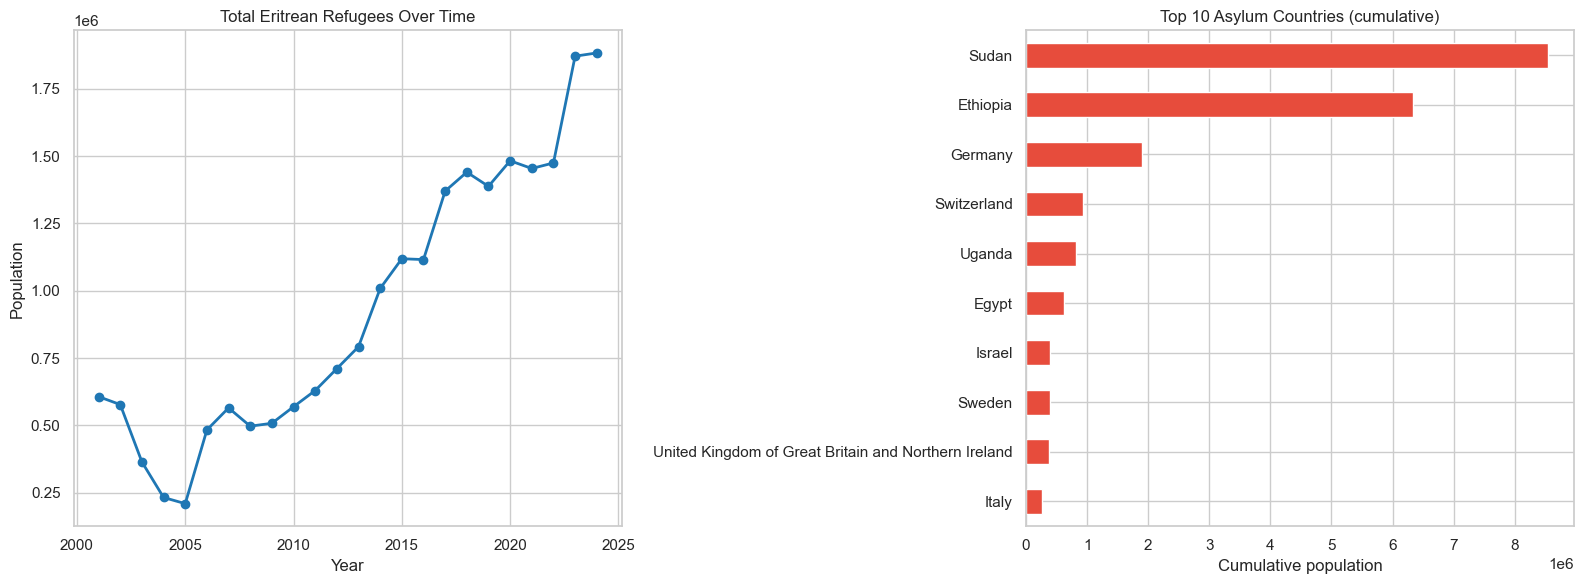

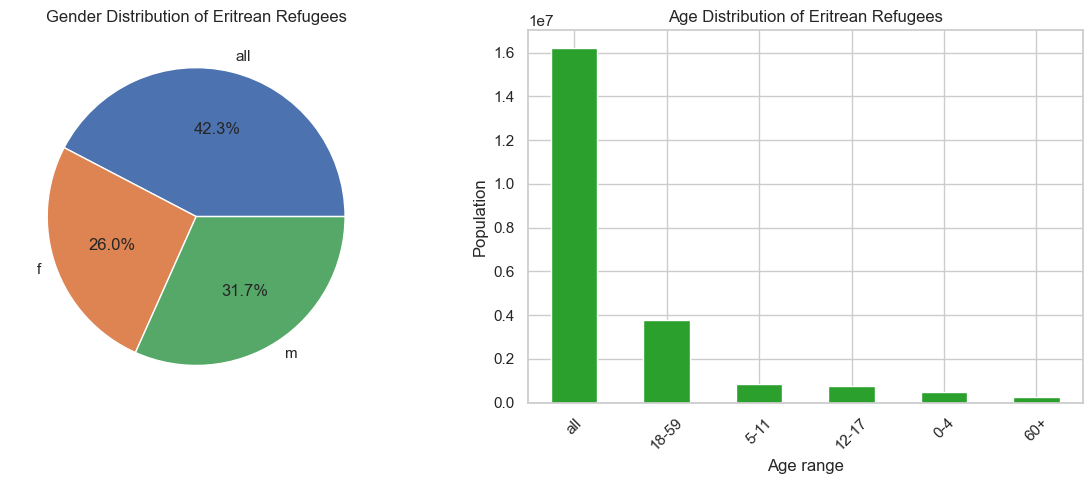


Summary: {'total_refugees': 22351825, 'top_country': 'Sudan', 'years_covered': 24, 'countries_involved': 118}


In [16]:
df = df_refugees.copy()

# Basic counts
print(f"Rows: {len(df)}")
print(f"Countries of asylum: {df['asylum_location_name'].nunique()}")
print(f"Years covered: {df['reference_period_start'].dt.year.nunique()}")

# Top asylum countries
top_countries = (
    df.groupby("asylum_location_name")["population"]
    .sum().sort_values(ascending=False).head(20)
)
print("\nTop 20 asylum countries:")
print(top_countries.to_string())

# Yearly trend
yearly_ref = (
    df.groupby(df["reference_period_start"].dt.year)["population"]
    .sum().reset_index(name="population")
)
yearly_ref.columns = ["year", "population"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

yearly_ref.plot(x="year", y="population", ax=axes[0], legend=False,
                color="#1f77b4", marker="o", linewidth=2)
axes[0].set_title("Total Eritrean Refugees Over Time")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Population")

top_countries.head(10).sort_values().plot(kind="barh", ax=axes[1], color="#e74c3c")
axes[1].set_title("Top 10 Asylum Countries (cumulative)")
axes[1].set_xlabel("Cumulative population"); axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "refugees_overview.png"), dpi=300)
plt.show()

# Gender & age breakdown
gender = df.groupby("gender")["population"].sum()
age    = df.groupby("age_range")["population"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gender.plot(kind="pie", autopct="%1.1f%%", ax=axes[0])
axes[0].set_title("Gender Distribution of Eritrean Refugees")
axes[0].set_ylabel("")

age.plot(kind="bar", ax=axes[1], color="#2ca02c")
axes[1].set_title("Age Distribution of Eritrean Refugees")
axes[1].set_xlabel("Age range"); axes[1].set_ylabel("Population")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "refugees_demographics.png"), dpi=300)
plt.show()

# Summary stats
summary = {
    "total_refugees":    int(df["population"].sum()),
    "top_country":       df.groupby("asylum_location_name")["population"].sum().idxmax(),
    "years_covered":     df["reference_period_start"].dt.year.nunique(),
    "countries_involved": df["asylum_location_name"].nunique(),
}
print("\nSummary:", summary)